# NYC Street Tree Census 2015 Exploratory Data Analysis (EDA) and Data Cleaning

This notebook performs a comprehensive exploratory data analysis (EDA) on the **2015 NYC Street Tree Census** dataset.  
Full data science pipeline: from loading raw data to feature engineering.

## 1. Data Exploration and Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from imblearn.over_sampling import SMOTE

In [2]:
warnings.filterwarnings('ignore')

In [4]:
tree_census = pd.read_csv('/content/2015_Street_Tree_Census_clean.csv')

In [5]:
print(f'Full dataset shape: {tree_census.shape}')

Full dataset shape: (62634, 45)


In [6]:
tree_census.head()

,tree_id,block_id,created_at,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,spc_common,...,boro_ct,state,latitude,longitude,x_sp,y_sp,council district,census tract,bin,bbl
0,180683,348711,2015-08-27,3,0,OnCurb,Alive,Fair,Acer rubrum,red maple,...,"4,073,900",New York,40.723092,-73.844215,NaN,NaN,29.0,739,4052307.0,4.022210e+09
1,200540,315986,2015-09-03,21,0,OnCurb,Alive,Fair,Quercus palustris,pin oak,...,"4,097,300",New York,40.794111,-73.818679,NaN,NaN,19.0,973,4101931.0,4.044750e+09
2,204026,218365,2015-09-05,3,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,"3,044,900",New York,40.717581,-73.936608,NaN,NaN,34.0,449,3338310.0,3.028870e+09
3,204337,217969,2015-09-05,10,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,"3,044,900",New York,40.713537,-73.934456,NaN,NaN,34.0,449,3338342.0,3.029250e+09
4,189565,223043,2015-08-30,21,0,OnCurb,Alive,Good,Tilia americana,American linden,...,"3,016,500",New York,40.666778,-73.975979,NaN,NaN,39.0,165,3025654.0,3.010850e+09


In [7]:
# Columns of interest
COLS = [
    'tree_id', 'tree_dbh', 'stump_diam',
    'curb_loc', 'status', 'health', 'spc_latin',
    'steward', 'sidewalk', 'problems',
    'root_stone', 'root_grate', 'root_other',
    'trunk_wire', 'trnk_light', 'trnk_other',
    'brch_light', 'brch_shoe', 'brch_other'
]

In [8]:
df = tree_census[COLS].copy()
print(f'Subset shape: {df.shape}')

Subset shape: (62634, 19)


In [9]:
df.head()

,tree_id,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,steward,sidewalk,problems,root_stone,root_grate,root_other,trunk_wire,trnk_light,trnk_other,brch_light,brch_shoe,brch_other
0,180683,3,0,OnCurb,Alive,Fair,Acer rubrum,NaN,NoDamage,NaN,No,No,No,No,No,No,No,No,No
1,200540,21,0,OnCurb,Alive,Fair,Quercus palustris,NaN,Damage,Stones,Yes,No,No,No,No,No,No,No,No
2,204026,3,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,1or2,Damage,NaN,No,No,No,No,No,No,No,No,No
3,204337,10,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,NaN,Damage,Stones,Yes,No,No,No,No,No,No,No,No
4,189565,21,0,OnCurb,Alive,Good,Tilia americana,NaN,Damage,Stones,Yes,No,No,No,No,No,No,No,No


In [14]:
# Numerical values and categorical values
print('Column data types:')
print(df.dtypes)

Column data types:
tree_id        int64
tree_dbh       int64
stump_diam     int64
curb_loc      object
status        object
health        object
spc_latin     object
steward       object
sidewalk      object
problems      object
root_stone    object
root_grate    object
root_other    object
trunk_wire    object
trnk_light    object
trnk_other    object
brch_light    object
brch_shoe     object
brch_other    object
dtype: object


## 2. Descriptive Statistics

Summary statistics for all columns

tree_dbh and stump_diam are in INCHES (1 inch = 2.54 cm)

In [12]:
# df.describe()
df.describe(include='all')

,tree_id,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,steward,sidewalk,problems,root_stone,root_grate,root_other,trunk_wire,trnk_light,trnk_other,brch_light,brch_shoe,brch_other
count,62634.000000,62634.000000,62634.000000,62634,62634,59417,59418,18332,59418,25438,62634,62634,62634,62634,62634,62634,62634,62634,62634
unique,NaN,NaN,NaN,2,3,3,125,3,2,140,2,2,2,2,2,2,2,2,2
top,NaN,NaN,NaN,OnCurb,Alive,Good,Platanus x acerifolia,1or2,NoDamage,Stones,No,No,No,No,No,No,No,No,No
freq,NaN,NaN,NaN,59961,59418,44963,7788,15468,40766,10209,46948,62060,58429,61210,62501,59067,55755,62590,59373
mean,214797.349938,11.253217,0.479500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,33233.406469,8.546495,3.401837,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,9.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,198880.250000,5.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,217473.000000,10.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,236560.750000,16.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
for col in df.columns:
    print(col, df[col].unique())

tree_id [180683 200540 204026 ... 242320 255709 263630]
tree_dbh [  3  21  10  11   9   6   8  13  22  30  12   2  14   4   5  33  19   7
   0  24  20  36  29  18  17  32  28  26  25  15  16  42  38  23  27   1
  37  39  35  31  34  41  44  43 425  50  51  40  72  45 122 169  46  47
  48 177  49  99 282  56  64  54  89  91 110  57  60  61  58  63]
stump_diam [  0  16  15  30  10  25  17   5   1  20   3  21   4   7   6  23  35  12
  11   9  14   8  22  19  18  27  24  36  41  40  13  37  44  26  38  29
  48  34  52   2  55  31  50  72  28 100  43  32  53  70 140  39  33  45
  47  42  90  46  58  74  54  64  57  49  77]
curb_loc ['OnCurb' 'OffsetFromCurb']
status ['Alive' 'Stump' 'Dead']
health ['Fair' 'Good' 'Poor' nan]
spc_latin ['Acer rubrum' 'Quercus palustris' 'Gleditsia triacanthos var. inermis'
 'Tilia americana' 'Platanus x acerifolia' 'Ginkgo biloba'
 'Quercus phellos' 'Acer pseudoplatanus' 'Acer ginnala' nan
 'Acer campestre' 'Ulmus americana' 'Fraxinus' 'Malus' 'Acer saccharin

## 3. Handling Missing Values

In [15]:
# Count NaNs per column
missing = df.isna().sum() #.sort_values(ascending=False)
missing

,0
tree_id,0
tree_dbh,0
stump_diam,0
curb_loc,0
status,0
health,3217
spc_latin,3216
steward,44302
sidewalk,3216
problems,37196


In [16]:
missing = df.isna().sum().sort_values(ascending=False)
# 2 dec values
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

           Missing Count  Missing %
steward            44302      70.73
problems           37196      59.39
health              3217       5.14
sidewalk            3216       5.13
spc_latin           3216       5.13


In [17]:
# Check for null values (isnull is an alias for isna — confirming both)
print('Null check (isnull):')
print(df.isnull().sum().sort_values(ascending=False))

Null check (isnull):
steward       44302
problems      37196
health         3217
sidewalk       3216
spc_latin      3216
tree_id           0
tree_dbh          0
stump_diam        0
status            0
curb_loc          0
root_stone        0
root_grate        0
root_other        0
trunk_wire        0
trnk_light        0
trnk_other        0
brch_light        0
brch_shoe         0
brch_other        0
dtype: int64


Are NaNs linked to Stumps and Dead trees?

Stumps and dead trees have no health/species info → expected NaNs

In [18]:
stumps    = df[df['status'] == 'Stump']
dead_trees = df[df['status'] == 'Dead']
alive      = df[df['status'] == 'Alive']

In [19]:
print(f"Stumps:     {len(stumps):>6}  | health NaN: {stumps['health'].isna().sum()}")
print(f"Dead trees: {len(dead_trees):>6}  | health NaN: {dead_trees['health'].isna().sum()}")
print(f"Alive:      {len(alive):>6}  | health NaN: {alive['health'].isna().sum()}")

Stumps:       1840  | health NaN: 1840
Dead trees:   1376  | health NaN: 1376
Alive:       59418  | health NaN: 1


In [21]:
# Strategy for handling missing values
#
# 'health', 'spc_latin', 'steward', 'sidewalk', 'problems':
#   These are NaN because the tree is a Stump or Dead — structurally missing (MNAR).
#   → Fill with 'Unknown' to preserve the rows; they still carry useful status info.
#
# Problem flag columns (root_stone, root_grate, etc.):
#   Also tied to stumps/dead trees → fill with 'No' (no problem recorded).
#
# 'tree_dbh' alive with value 0:
#   Biologically impossible for a living tree → treated as missing, imputed with median.

cat_fill_unknown = ['health', 'spc_latin', 'steward', 'sidewalk', 'problems']
df[cat_fill_unknown] = df[cat_fill_unknown].fillna('Unknown')

PROBLEM_COLS = [
    'root_stone', 'root_grate', 'root_other',
    'trunk_wire', 'trnk_light', 'trnk_other',
    'brch_light', 'brch_shoe', 'brch_other'
]
df[PROBLEM_COLS] = df[PROBLEM_COLS].fillna('No')

# Impute tree_dbh = 0 for alive trees with the median of alive trees
alive_median_dbh = df.loc[(df['status'] == 'Alive') & (df['tree_dbh'] > 0), 'tree_dbh'].median()
mask_zero_alive  = (df['status'] == 'Alive') & (df['tree_dbh'] == 0)
df.loc[mask_zero_alive, 'tree_dbh'] = alive_median_dbh
print(f"Imputed {mask_zero_alive.sum()} zero-DBH alive trees with median: {alive_median_dbh} in")

print(f"\nRemaining NaNs after cleaning:")
print(df.isna().sum().sort_values(ascending=False).head(10))

Imputed 9 zero-DBH alive trees with median: 10.0 in

Remaining NaNs after cleaning:
tree_id       0
tree_dbh      0
stump_diam    0
curb_loc      0
status        0
health        0
spc_latin     0
steward       0
sidewalk      0
problems      0
dtype: int64


# 4. Duplicate Check

In [22]:
# Check for full-row duplicates
n_dupes = df.duplicated().sum()
print(f'Full-row duplicates: {n_dupes}')

# Check for duplicate tree_id (each tree should be unique)
n_id_dupes = df.duplicated(subset='tree_id').sum()
print(f'Duplicate tree_id:   {n_id_dupes}')

if n_dupes > 0:
    df = df.drop_duplicates()
    print(f'Dropped {n_dupes} duplicate rows. New shape: {df.shape}')
else:
    print('No duplicates found — dataset is clean.')

Full-row duplicates: 0
Duplicate tree_id:   0
No duplicates found — dataset is clean.


## 5. Data Visualization Techniques

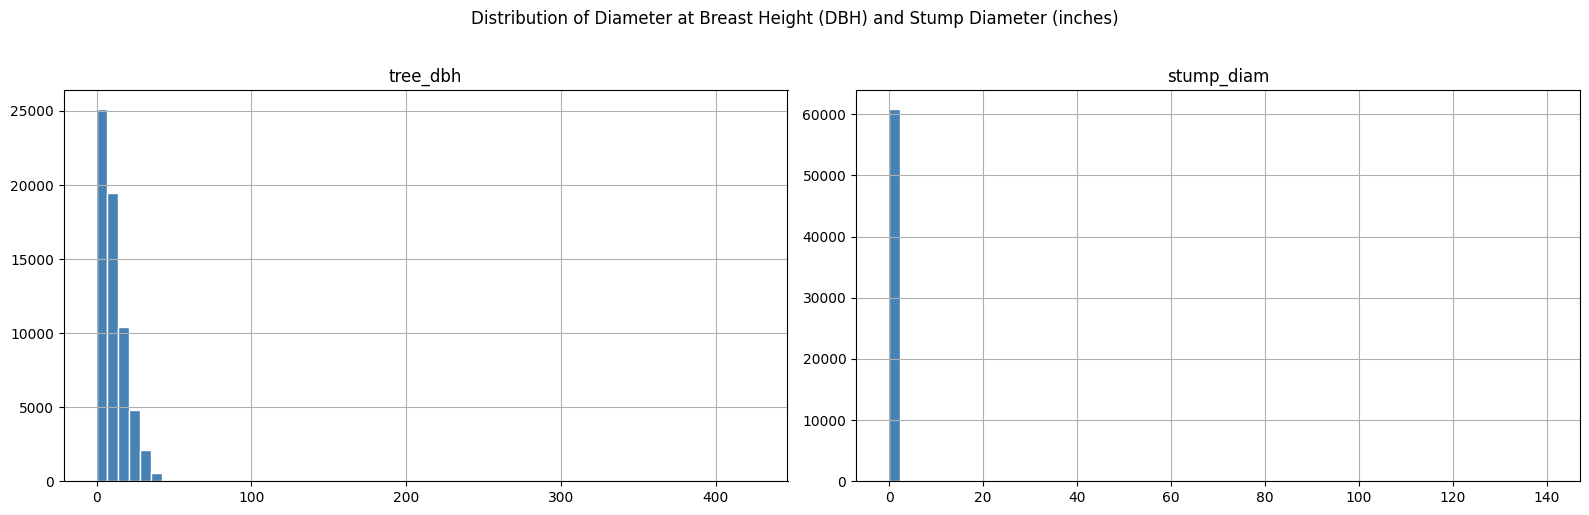

In [23]:
# Histograms for numeric features
df[['tree_dbh', 'stump_diam']].hist(bins=60, figsize=(16, 5), color='steelblue', edgecolor='white')
plt.suptitle('Distribution of Diameter at Breast Height (DBH) and Stump Diameter (inches)', y=1.02)
plt.tight_layout()
plt.show()

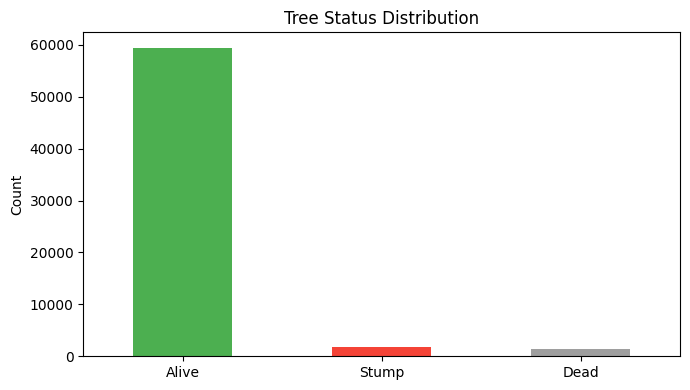

In [24]:
# Tree status distribution
fig, ax = plt.subplots(figsize=(7, 4))
df['status'].value_counts().plot(kind='bar', ax=ax, color=['#4caf50','#f44336','#9e9e9e'])
ax.set_title('Tree Status Distribution')
ax.set_xlabel('')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

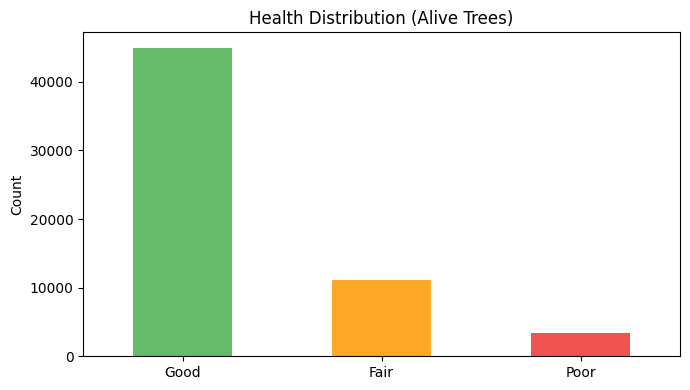

In [25]:
# Health distribution (alive trees only)
fig, ax = plt.subplots(figsize=(7, 4))
alive['health'].value_counts().plot(kind='bar', ax=ax, color=['#66bb6a','#ffa726','#ef5350'])
ax.set_title('Health Distribution (Alive Trees)')
ax.set_xlabel('')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

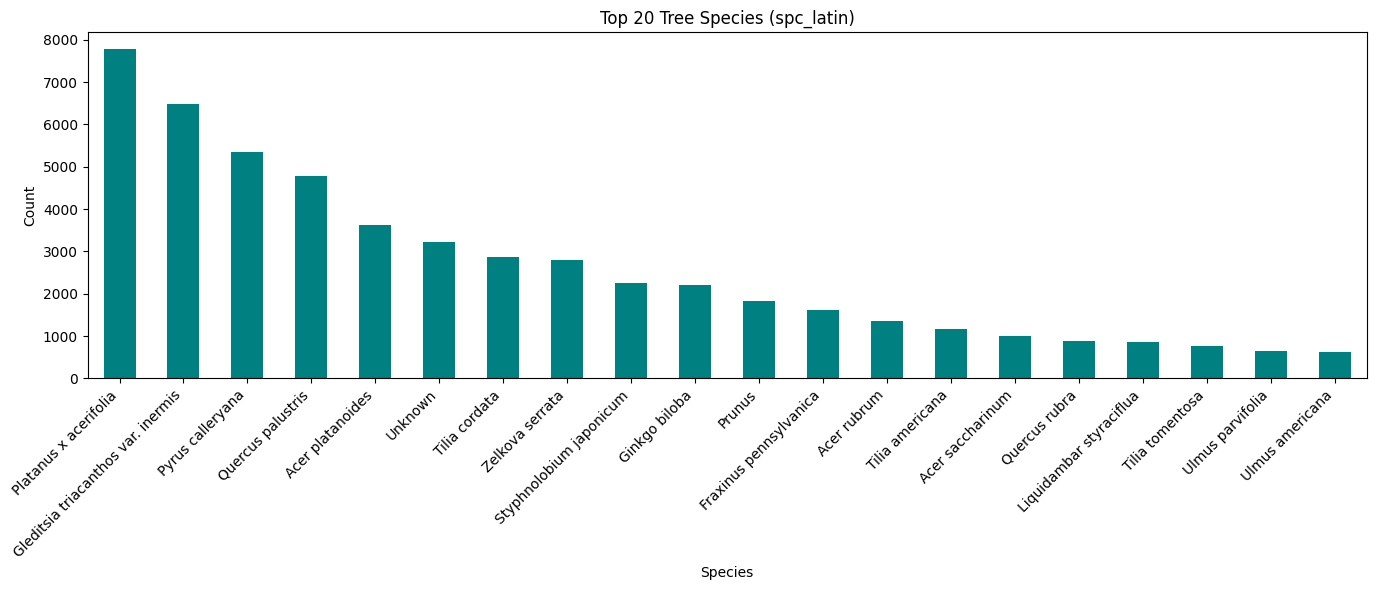

In [26]:
# Top 20 species by count
top20 = df['spc_latin'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(14, 6))
top20.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Top 20 Tree Species (spc_latin)')
ax.set_xlabel('Species')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Outlier Detection

Are very large trees real or data-entry errors?

Threshold: DBH > 50 inches (≈ 127 cm) is unusual but possible for mature oaks etc.

In [29]:
big_trees = df[df['tree_dbh'] > 50]
print(f'Trees with DBH > 50 inches: {len(big_trees)}')
big_trees[['tree_id', 'tree_dbh', 'spc_latin', 'status', 'health']].head(20)

Trees with DBH > 50 inches: 25


,tree_id,tree_dbh,spc_latin,status,health
2405,168583,425,Quercus bicolor,Alive,Good
3738,199546,51,Acer saccharinum,Alive,Good
4887,139665,72,Acer saccharinum,Alive,Good
6724,209349,122,Quercus palustris,Alive,Good
10083,215075,169,Gleditsia triacanthos var. inermis,Alive,Good
20379,215697,51,Acer rubrum,Alive,Good
25862,214532,177,Robinia pseudoacacia,Alive,Fair
27708,220146,51,Platanus x acerifolia,Alive,Good
29669,215564,99,Juniperus virginiana,Alive,Poor
29973,214534,282,Platanus x acerifolia,Alive,Good


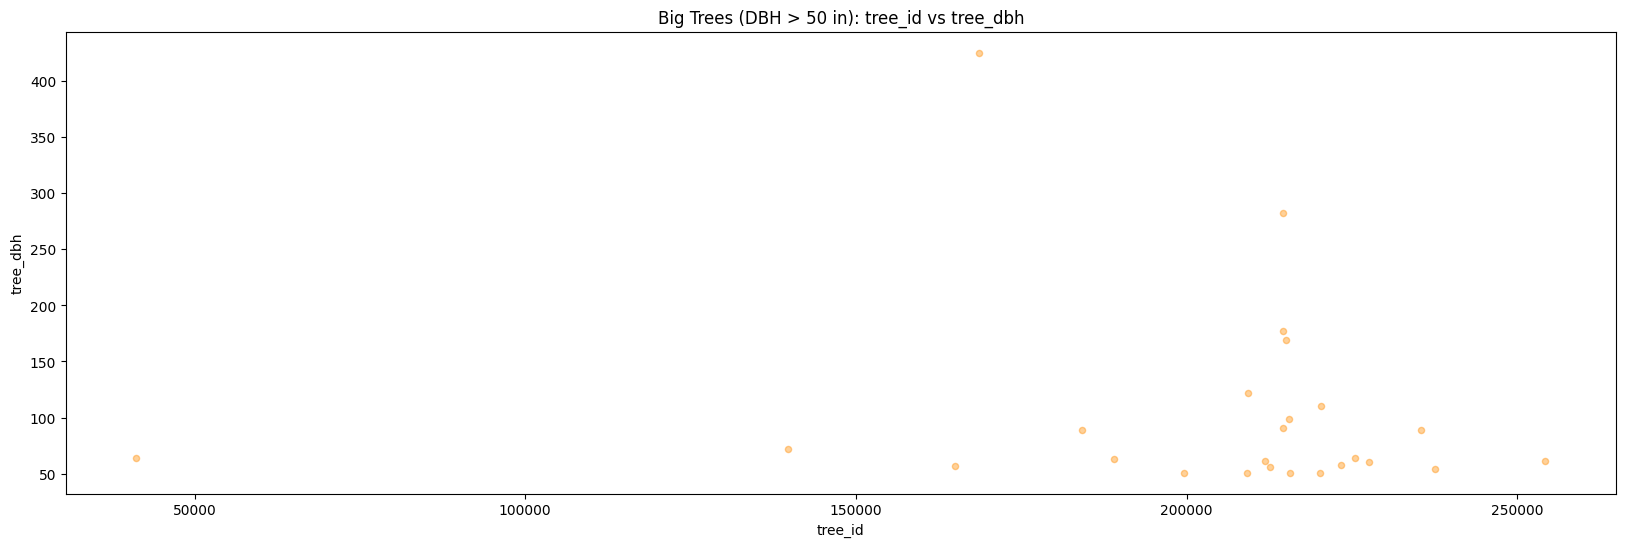

In [30]:
big_trees[['tree_id', 'tree_dbh']].plot(
    kind='scatter', x='tree_id', y='tree_dbh', figsize=(20, 6),
    alpha=0.4, color='darkorange'
)
plt.title('Big Trees (DBH > 50 in): tree_id vs tree_dbh')
plt.show()

Stumps with stump_diam > 50 inches: 18


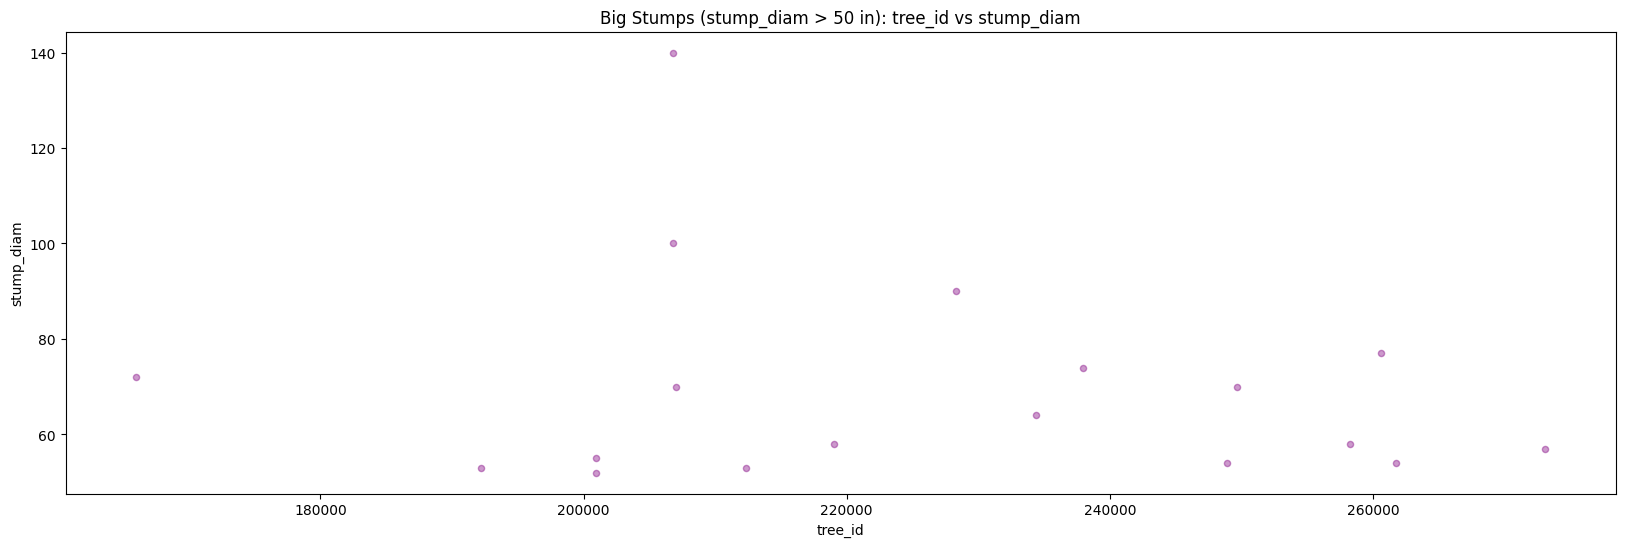

In [31]:
big_trees_stump = df[df['stump_diam'] > 50]
print(f'Stumps with stump_diam > 50 inches: {len(big_trees_stump)}')
big_trees_stump[['tree_id', 'stump_diam']].plot(
    kind='scatter', x='tree_id', y='stump_diam', figsize=(20, 6),
    alpha=0.4, color='purple'
)
plt.title('Big Stumps (stump_diam > 50 in): tree_id vs stump_diam')
plt.show()

In [32]:
# ── Outlier detection: IQR method (best choice for skewed data like tree_dbh) ─
#
# Why IQR and not Z-score?
#   tree_dbh is heavily right-skewed (most trees are small, few are very large).
#   Z-score assumes a normal distribution — it underestimates outliers on skewed data.
#   IQR is distribution-agnostic and robust: the standard in environmental / census datasets.
#
# Why not Isolation Forest here?
#   Isolation Forest is multivariate — great when you have many numeric features.
#   We have only two numeric columns (tree_dbh, stump_diam), so IQR is simpler and more interpretable.
#
# Treatment: Winsorization (capping at fence) — industry standard when you
#   cannot verify whether an extreme value is a true measurement or a data-entry error.
#   We do NOT drop rows because the tree may still hold valid categorical information.

alive_mask = df['status'] == 'Alive'

for col in ['tree_dbh', 'stump_diam']:
    Q1  = df.loc[alive_mask, col].quantile(0.25)
    Q3  = df.loc[alive_mask, col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR

    n_out = ((df.loc[alive_mask, col] < lo) | (df.loc[alive_mask, col] > hi)).sum()
    print(f'{col}: IQR fence [{lo:.1f}, {hi:.1f}]  →  {n_out} outliers')

    # Winsorize: clip only alive trees
    df.loc[alive_mask, col] = df.loc[alive_mask, col].clip(lower=max(lo, 0), upper=hi)

print('\nAfter Winsorization:')
print(df.loc[alive_mask, ['tree_dbh', 'stump_diam']].describe())

tree_dbh: IQR fence [-11.5, 32.5]  →  1286 outliers
stump_diam: IQR fence [0.0, 0.0]  →  0 outliers

After Winsorization:
           tree_dbh  stump_diam
count  59418.000000     59418.0
mean      11.625147         0.0
std        7.839192         0.0
min        1.000000         0.0
25%        5.000000         0.0
50%       10.000000         0.0
75%       16.000000         0.0
max       32.500000         0.0


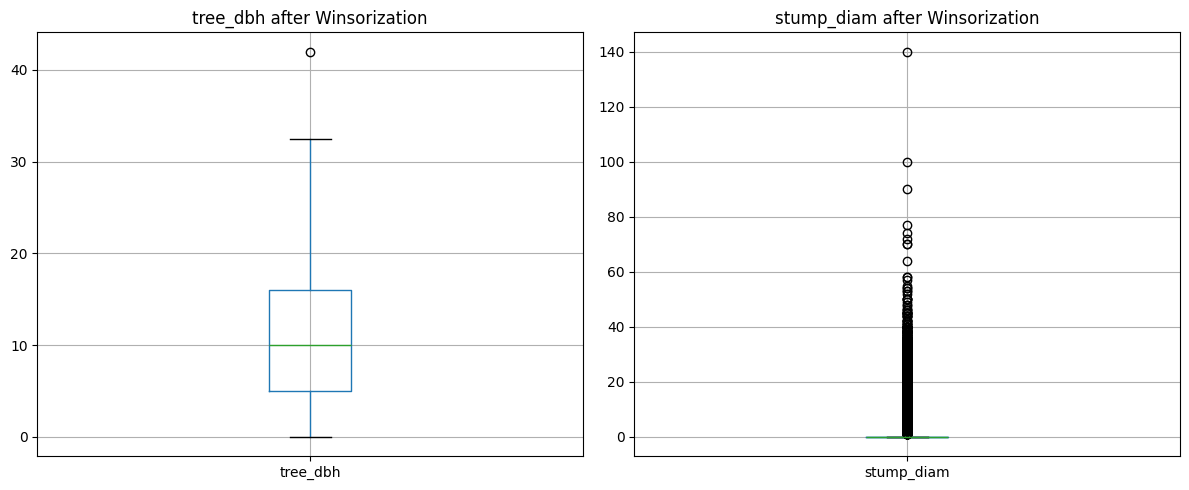

In [33]:
# Visual confirmation: box plots before/after are reflected in the clipped distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df.boxplot(column='tree_dbh',   ax=axes[0])
axes[0].set_title('tree_dbh after Winsorization')
df.boxplot(column='stump_diam', ax=axes[1])
axes[1].set_title('stump_diam after Winsorization')
plt.tight_layout()
plt.show()

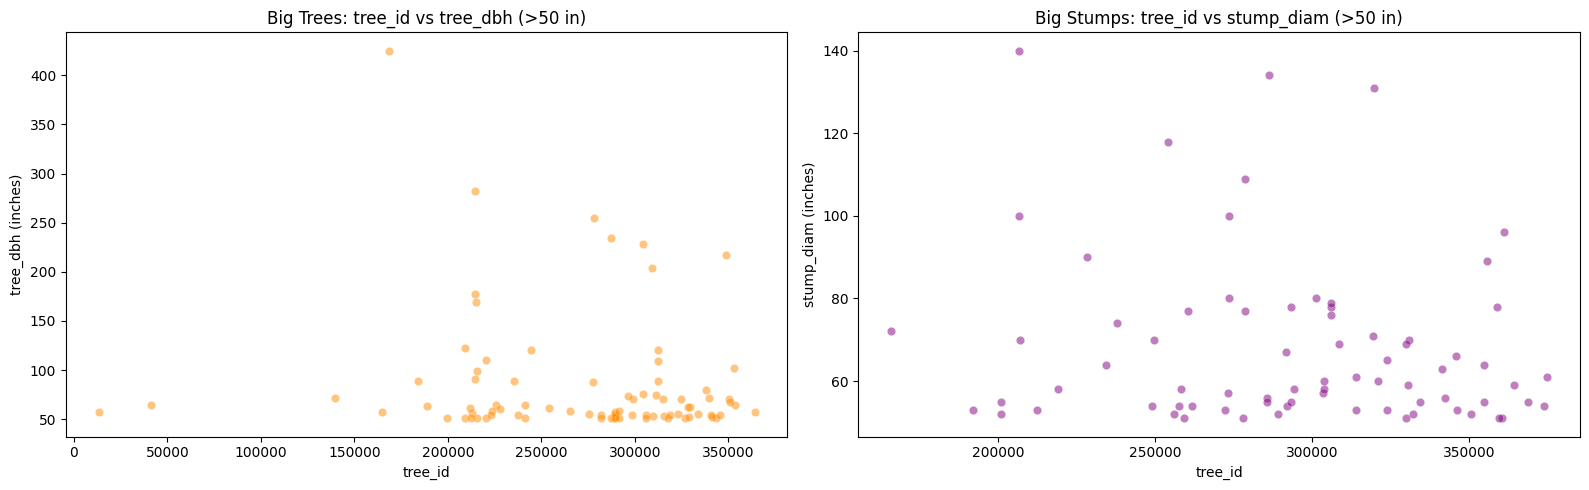

Stumps with stump_diam > 50 inches: 74


In [ ]:
# Scatter plot: tree_id vs tree_dbh for big trees
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(big_trees_dbh['tree_id'], big_trees_dbh['tree_dbh'],
                alpha=0.5, color='darkorange', edgecolors='white', linewidth=0.3)
axes[0].set_title('Big Trees: tree_id vs tree_dbh (>50 in)')
axes[0].set_xlabel('tree_id')
axes[0].set_ylabel('tree_dbh (inches)')

big_stumps = df[df['stump_diam'] > 50]
axes[1].scatter(big_stumps['tree_id'], big_stumps['stump_diam'],
                alpha=0.5, color='purple', edgecolors='white', linewidth=0.3)
axes[1].set_title('Big Stumps: tree_id vs stump_diam (>50 in)')
axes[1].set_xlabel('tree_id')
axes[1].set_ylabel('stump_diam (inches)')

plt.tight_layout()
plt.show()

print(f'Stumps with stump_diam > 50 inches: {len(big_stumps)}')

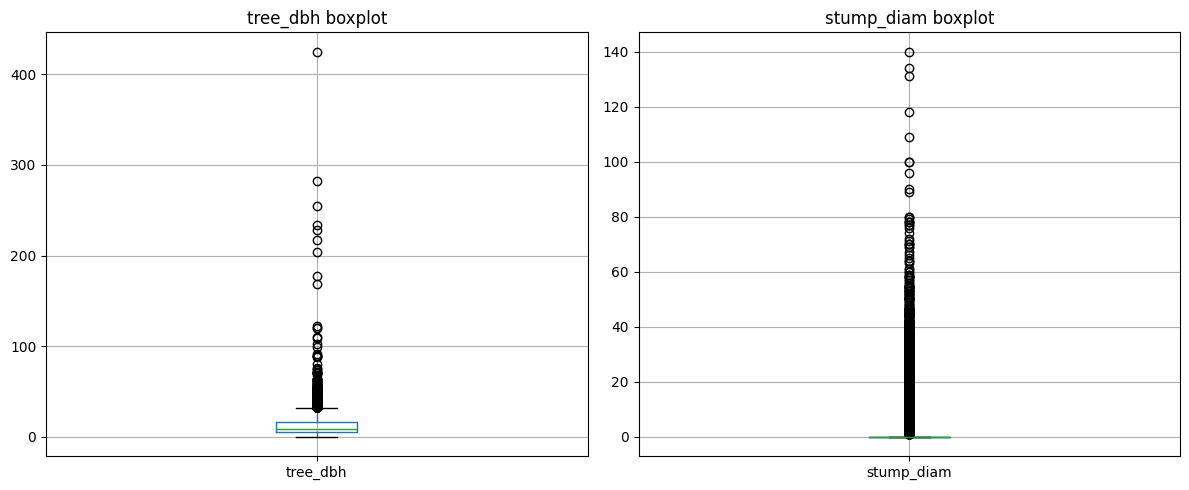

In [ ]:
# Box plots for numeric columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df.boxplot(column='tree_dbh', ax=axes[0])
axes[0].set_title('tree_dbh boxplot')
df.boxplot(column='stump_diam', ax=axes[1])
axes[1].set_title('stump_diam boxplot')
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

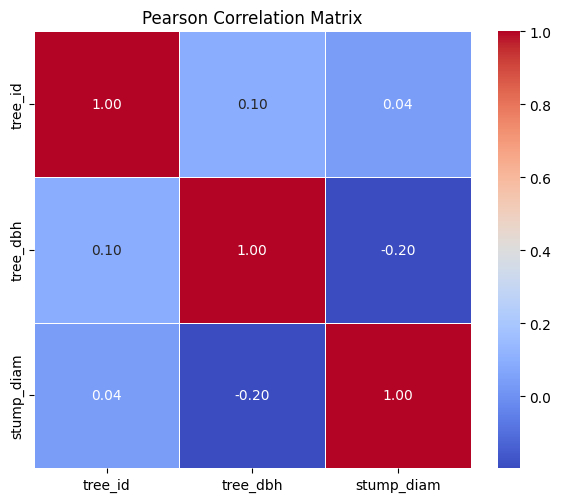

In [34]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

# 8. Encoding Categorical Variables

In [35]:
# Ordinal encoding: health
health_map = {'Poor': 1,
              'Fair': 2,
              'Good': 3}
df['health_enc'] = df['health'].map(health_map)
print('health → health_enc mapping:')
print(df[['health', 'health_enc']].value_counts().sort_index())

health → health_enc mapping:
health  health_enc
Fair    2.0           11098
Good    3.0           44963
Poor    1.0            3356
Name: count, dtype: int64


In [37]:
# Problem columns value counts — raw
print('Raw value counts across problem columns:')
print(df[PROBLEM_COLS].apply(pd.Series.value_counts))

Raw value counts across problem columns:
     root_stone  root_grate  root_other  trunk_wire  trnk_light  trnk_other  \
No        46948       62060       58429       61210       62501       59067   
Yes       15686         574        4205        1424         133        3567   

     brch_light  brch_shoe  brch_other  
No        55755      62590       59373  
Yes        6879         44        3261  


In [38]:
# Encode Yes/No → 1/0
yn_map = {'Yes': 1, 'No': 0}
df[PROBLEM_COLS] = df[PROBLEM_COLS].replace(yn_map)
df[PROBLEM_COLS].head()

,root_stone,root_grate,root_other,trunk_wire,trnk_light,trnk_other,brch_light,brch_shoe,brch_other
0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0


## 9. Data Scaling and Normalization

In [39]:
# Standard scaling (z-score norm)
scaler_std = StandardScaler()
df[['tree_dbh_scaled', 'stump_diam_scaled']] = scaler_std.fit_transform(
    df[['tree_dbh', 'stump_diam']]
)

In [40]:
# Min-Max scaling
scaler_mm = MinMaxScaler()
df[['tree_dbh_norm', 'stump_diam_norm']] = scaler_mm.fit_transform(
    df[['tree_dbh', 'stump_diam']]
)

In [41]:
print('Original vs scaled values:')
df[['tree_dbh', 'tree_dbh_scaled', 'tree_dbh_norm']].describe().round(3)

Original vs scaled values:


,tree_dbh,tree_dbh_scaled,tree_dbh_norm
count,62634.000,62634.000,62634.000
mean,11.150,0.000,0.265
std,7.958,1.000,0.189
min,0.000,-1.401,0.000
25%,5.000,-0.773,0.119
50%,10.000,-0.144,0.238
75%,16.000,0.609,0.381
max,42.000,3.877,1.000


# 10. Feature Engineering

In [42]:
# Total number of problems per tree
df['total_problems'] = df[PROBLEM_COLS].sum(axis=1)
print('Problem count distribution:')
print(df['total_problems'].value_counts() )#.sort_index())

Problem count distribution:
total_problems
0    37196
1    17514
2     5913
3     1654
4      319
5       33
6        5
Name: count, dtype: int64


In [43]:
# Convert DBH from inches to centimeters
df['tree_dbh_cm'] = df['tree_dbh'] * 2.54

size_category ['Sapling', 'Medium', 'Small', 'Large', NaN]

Categories (4, object): ['Sapling' < 'Small' < 'Medium' < 'Large']

In [44]:
# Size category
bins   = [0, 3, 10, 30, np.inf]
labels = ['Sapling', 'Small', 'Medium', 'Large']
df['size_category'] = pd.cut(df['tree_dbh'], bins=bins, labels=labels)

In [45]:
print('Size category distribution:')
print(df['size_category'].value_counts().sort_index())

Size category distribution:
size_category
Sapling     8505
Small      23515
Medium     26773
Large       1993
Name: count, dtype: int64


Is the tree a stump?

In [47]:
# Binary flags
df['is_stump']    = (df['status'] == 'Stump').astype(int)
df['has_problem'] = (df['total_problems'] > 0).astype(int)

print('New binary feature counts:')
print(df[['is_stump', 'has_problem']].sum())

New binary feature counts:
is_stump        1840
has_problem    25438
dtype: int64


# 11. Handling Class Imbalance

Health class distribution (alive trees):
health_enc
1.0     3356
2.0    11098
3.0    44963
Name: count, dtype: int64


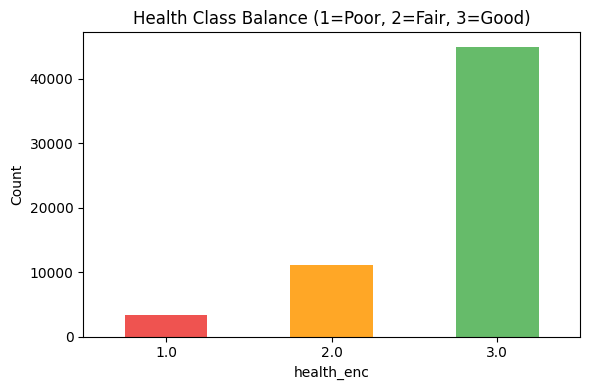

In [49]:
# Check if health classes are imbalanced (alive trees only, encoded)
alive_df = df[df['status'] == 'Alive'].copy()
print('Health class distribution (alive trees):')
print(alive_df['health_enc'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(6, 4))
alive_df['health_enc'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color=['#ef5350', '#ffa726', '#66bb6a']
)
ax.set_title('Health Class Balance (1=Poor, 2=Fair, 3=Good)')
ax.set_xlabel('health_enc')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Class distribution BEFORE SMOTE:
health_enc
1.0     3356
2.0    11098
3.0    44963
Name: count, dtype: int64

Class distribution AFTER SMOTE:
health_enc
1.0    44963
2.0    44963
3.0    44963
Name: count, dtype: int64


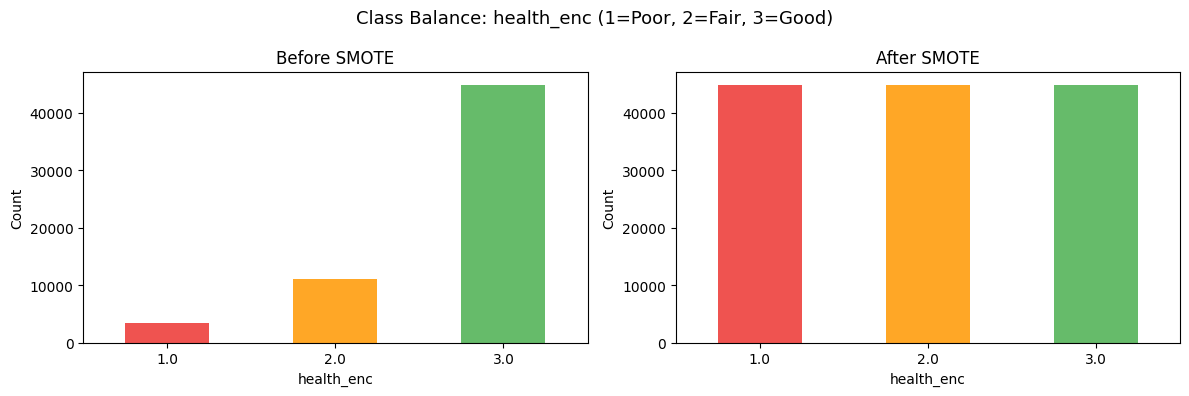

In [50]:
# ── SMOTE — Synthetic Minority Over-sampling Technique ────────────────────────
#
# If 'Good' trees vastly outnumber 'Poor' and 'Fair', a classifier trained on
# raw data will simply predict 'Good' for everything and still score high accuracy.
# SMOTE creates synthetic samples of minority classes in feature space
# (not just duplicating rows) so each class is equally represented.
#
# We use the numeric problem flags + tree_dbh as features,
# and health_enc as the target label.
#
# Note: SMOTE is applied only to the alive subset with valid health labels.

feature_cols = PROBLEM_COLS + ['tree_dbh_scaled']

X_imb = alive_df[feature_cols].fillna(0)
y_imb = alive_df['health_enc'].dropna()

# Align index
X_imb = X_imb.loc[y_imb.index]

# Remove class 0 (Unknown) — not a real health label
mask_valid = y_imb > 0
X_imb = X_imb[mask_valid]
y_imb = y_imb[mask_valid]

print('Class distribution BEFORE SMOTE:')
print(y_imb.value_counts().sort_index())

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_imb, y_imb)

print('\nClass distribution AFTER SMOTE:')
print(pd.Series(y_res).value_counts().sort_index())

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y_imb.value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['#ef5350','#ffa726','#66bb6a'])
axes[0].set_title('Before SMOTE')
axes[0].set_xlabel('health_enc')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

pd.Series(y_res).value_counts().sort_index().plot(kind='bar', ax=axes[1], color=['#ef5350','#ffa726','#66bb6a'])
axes[1].set_title('After SMOTE')
axes[1].set_xlabel('health_enc')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Class Balance: health_enc (1=Poor, 2=Fair, 3=Good)', fontsize=13)
plt.tight_layout()
plt.show()

# **FINAL**

Final Summary: All Engineered & Key Columns

In [51]:
final_cols = [
    # Identifier
    'tree_id',

    # Original numeric
    'tree_dbh',
    'stump_diam',

    # Converted / scaled
    'tree_dbh_cm',
    'tree_dbh_scaled',
    'tree_dbh_norm',
    'stump_diam_scaled',
    'stump_diam_norm',

    # Categorical (original)
    'curb_loc',
    'status',
    'health',
    'spc_latin',
    'steward',
    'sidewalk',
    'problems',

    # Encoded categorical
    'health_enc',

    # Problem columns (encoded Yes/No → 1/0)
    'root_stone', 'root_grate', 'root_other',
    'trunk_wire', 'trnk_light', 'trnk_other',
    'brch_light', 'brch_shoe', 'brch_other',

    # Feature engineering
    'total_problems',
    'has_problem',
    'size_category',
    'is_stump',
]

In [52]:
df_final = df[final_cols].copy()

In [53]:
print('=' * 60)
print('  FINAL DATASET')
print('=' * 60)
print(f'  Rows:    {df_final.shape[0]:,}')
print(f'  Columns: {df_final.shape[1]}')
print('=' * 60)

print('\n── Column types ──────────────────────────────────────────')
print(df_final.dtypes)

print('\n── First 5 rows ──────────────────────────────────────────')
df_final.head()

  FINAL DATASET
  Rows:    62,634
  Columns: 29

── Column types ──────────────────────────────────────────
tree_id                 int64
tree_dbh              float64
stump_diam              int64
tree_dbh_cm           float64
tree_dbh_scaled       float64
tree_dbh_norm         float64
stump_diam_scaled     float64
stump_diam_norm       float64
curb_loc               object
status                 object
health                 object
spc_latin              object
steward                object
sidewalk               object
problems               object
health_enc            float64
root_stone              int64
root_grate              int64
root_other              int64
trunk_wire              int64
trnk_light              int64
trnk_other              int64
brch_light              int64
brch_shoe               int64
brch_other              int64
total_problems          int64
has_problem             int64
size_category        category
is_stump                int64
dtype: object

── Firs

,tree_id,tree_dbh,stump_diam,tree_dbh_cm,tree_dbh_scaled,tree_dbh_norm,stump_diam_scaled,stump_diam_norm,curb_loc,status,...,trunk_wire,trnk_light,trnk_other,brch_light,brch_shoe,brch_other,total_problems,has_problem,size_category,is_stump
0,180683,3.0,0,7.62,-1.024086,0.071429,-0.140954,0.0,OnCurb,Alive,...,0,0,0,0,0,0,0,0,Sapling,0
1,200540,21.0,0,53.34,1.237797,0.500000,-0.140954,0.0,OnCurb,Alive,...,0,0,0,0,0,0,1,1,Medium,0
2,204026,3.0,0,7.62,-1.024086,0.071429,-0.140954,0.0,OnCurb,Alive,...,0,0,0,0,0,0,0,0,Sapling,0
3,204337,10.0,0,25.40,-0.144465,0.238095,-0.140954,0.0,OnCurb,Alive,...,0,0,0,0,0,0,1,1,Small,0
4,189565,21.0,0,53.34,1.237797,0.500000,-0.140954,0.0,OnCurb,Alive,...,0,0,0,0,0,0,1,1,Medium,0


**func used:**

pd.read_csv('...')

.copy()

df.shape

df.head()

df.dtypes

df.describe(include='all')

df.value_counts()

df.unique()

df.isna().sum().sort_values(ascending=False)

df.isnull().sum()

df.isna().T

df.duplicated().sum()

df.drop_duplicates()

df[df['col'] == 'value']

df['col'].quantile([0.25, 0.75])

df['col'].clip(lower=..., upper=...)

df['col'].fillna('...')

df['col'].map({...})

df['col'].replace({...})

df[cols].sum(axis=1)

df[cols].apply(pd.Series.value_counts)

pd.cut(df['col'], bins=[...], labels=[...])

df.select_dtypes(include=[np.number])

df.corr()

df.boxplot(column='...')

df.hist(bins=60, figsize=(...))

.plot(kind='bar')

.plot(kind='scatter', x='...', y='...')

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')

sns.heatmap(df.isna().T, cbar=False)

StandardScaler().fit_transform(...)

MinMaxScaler().fit_transform(...)

SMOTE(random_state=42).fit_resample(X, y)

.astype(int)

.sort_index()

.round(2)